# 05. Comparación de Modelos y Resultados Finales

## Objetivo

El objetivo de esta etapa fue comparar el desempeño de los distintos modelos entrenados para identificar cuál ofrece el mejor equilibrio entre:

- Capacidad predictiva
- Detección de fraude
- Precisión operativa

Debido al fuerte desbalanceo del problema, la comparación se centró principalmente en:

- **ROC-AUC**
- **Recall de fraude**
- **Precision de fraude**
- **F1-score**

Más allá de accuracy, ya que esta métrica puede resultar engañosa en problemas altamente desbalanceados.


In [1]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LDA",
        "QDA",
        "KNN",
        "Random Forest",
        "XGBoost (Top 50)",
        "XGBoost (Full)"
    ],

    "ROC_AUC": [
        0.819,
        0.810,
        0.795,
        0.711,
        0.875,
        0.881,
        0.903
    ],

    "Precision_Fraud": [
        0.11,
        0.32,
        0.23,
        0.65,
        0.18,
        0.16,
        0.20
    ],

    "Recall_Fraud": [
        0.73,
        0.33,
        0.29,
        0.24,
        0.69,
        0.73,
        0.75
    ],

    "F1_Fraud": [
        0.19,
        0.32,
        0.26,
        0.35,
        0.28,
        0.27,
        0.31
    ]
})

results = results.sort_values(
    by="ROC_AUC",
    ascending=False
)

display(results)

,Model,ROC_AUC,Precision_Fraud,Recall_Fraud,F1_Fraud
6,XGBoost (Full),0.903,0.20,0.75,0.31
5,XGBoost (Top 50),0.881,0.16,0.73,0.27
4,Random Forest,0.875,0.18,0.69,0.28
0,Logistic Regression,0.819,0.11,0.73,0.19
1,LDA,0.810,0.32,0.33,0.32
2,QDA,0.795,0.23,0.29,0.26
3,KNN,0.711,0.65,0.24,0.35


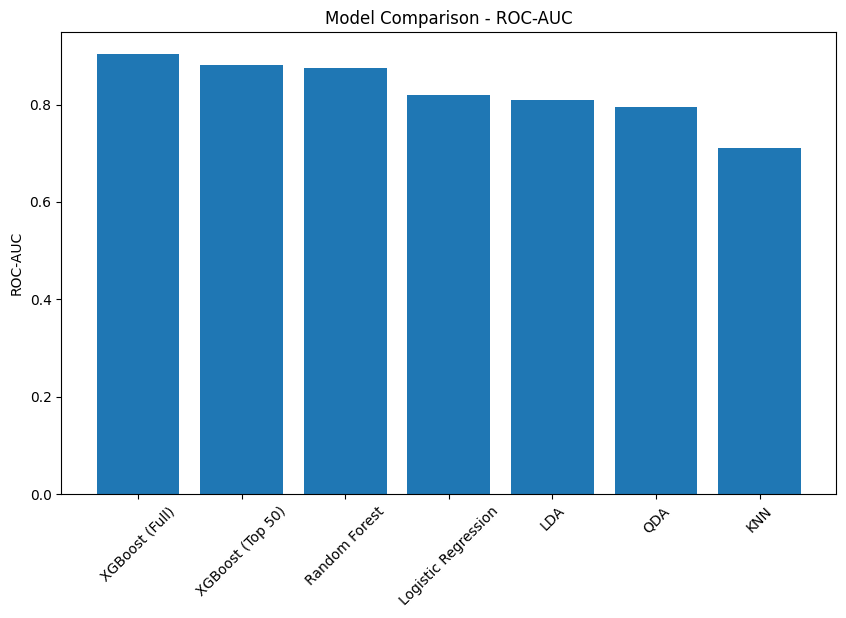

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    results["Model"],
    results["ROC_AUC"]
)

plt.xticks(rotation=45)

plt.ylabel("ROC-AUC")
plt.title("Model Comparison - ROC-AUC")

plt.show()

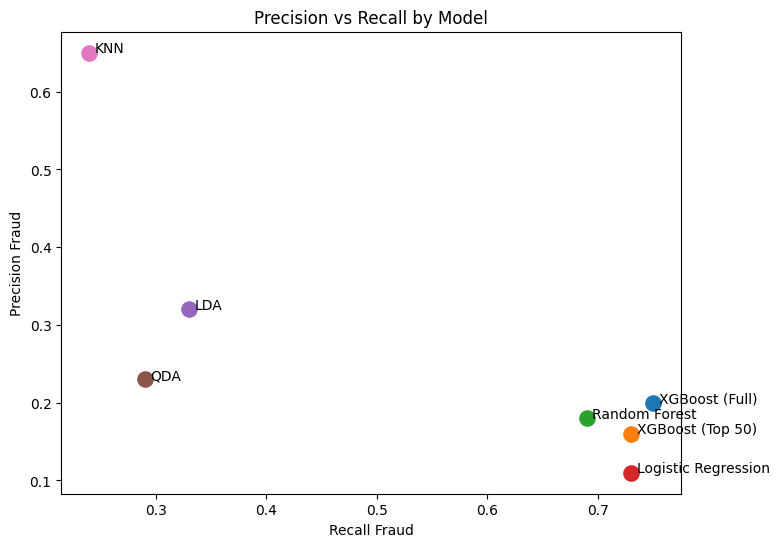

In [3]:
plt.figure(figsize=(8,6))

for i in range(len(results)):
    plt.scatter(
        results.iloc[i]["Recall_Fraud"],
        results.iloc[i]["Precision_Fraud"],
        s=120
    )

    plt.text(
        results.iloc[i]["Recall_Fraud"] + 0.005,
        results.iloc[i]["Precision_Fraud"],
        results.iloc[i]["Model"]
    )

plt.xlabel("Recall Fraud")
plt.ylabel("Precision Fraud")

plt.title(
    "Precision vs Recall by Model"
)

plt.show()

## Conclusión

En conclusión, el modelo recomendado para este proyecto es XGBoost utilizando el conjunto completo de 484 variables (XGBoost Full), ya que fue el que obtuvo el mejor desempeño global en la detección de fraude. El modelo alcanzó un ROC-AUC de 0.903 y un recall de 75%, resultados especialmente sólidos en un problema altamente desbalanceado como el fraude financiero, donde identificar la mayor cantidad posible de transacciones fraudulentas es una prioridad.

Además, el análisis de threshold tuning permitió observar que un umbral cercano a 0.30 podría ofrecer un mejor equilibrio desde la perspectiva de negocio, incrementando la capacidad de detección de fraude sin generar un aumento excesivo de falsos positivos. Esto demuestra que el modelo no solo presenta un alto rendimiento estadístico, sino también flexibilidad para adaptarse a distintos objetivos operativos y niveles de riesgo en un entorno real de detección de fraude.

No obstante, la reducción del threshold también implica un incremento en los falsos positivos, ya que el modelo clasifica una mayor cantidad de transacciones como fraudulentas. Aunque esto puede generar revisiones adicionales sobre operaciones legítimas, en el contexto de fraude financiero suele considerarse un intercambio razonable desde la perspectiva de negocio. En muchos casos, el costo asociado a no detectar una transacción fraudulenta es considerablemente mayor que el inconveniente de analizar manualmente algunas operaciones legítimas. Por ello, ajustar el umbral de decisión permite adaptar el modelo al nivel de riesgo que la organización está dispuesta a asumir, buscando un equilibrio entre capacidad de detección y experiencia del usuario.